# Capstone Project_02

### Sentiment Analysis of E-commerce Product Reviews using Machine Learning and Deep Learning

**load the important libraries**

In [1]:
# load the libraries for data handling
import numpy as np
import pandas as pd
# load the libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt

### load the datasets

In [2]:
# load the datasets
trainDf=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Digicrome_Capstone Project\Capstone Project_2\train_data.csv")
testDf=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Digicrome_Capstone Project\Capstone Project_2\test_data.csv")
hiddenDf=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Digicrome_Capstone Project\Capstone Project_2\test_data_hidden.csv")

In [3]:
# complete rows and columns
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)
pd.set_option("display.max_colwidth",None)
# It'll display the complete rows as well as columns

### dimensions

In [4]:
print(trainDf.shape,testDf.shape,hiddenDf.shape)
# It'll display the total number of rows and columns.We've 4000 rows and 8 columns in trainDf,1000 rows and 7 columns in testDf and 1000 rows and 8 columns in hiddenDf

(4000, 8) (1000, 7) (1000, 8)


In [5]:
# trainDf
print("Total no of rows in trainDf:",trainDf.shape[0])
print("Total no of columns in trainDf:",trainDf.shape[1])

# testDf
print("Total no of rows in testDf:",testDf.shape[0])
print("Total no of columns in testDf:",testDf.shape[1])

# hiddenDf
print("Total no of rows in hiddenDf:",hiddenDf.shape[0])
print("Total no of columns in hiddenDf:",hiddenDf.shape[1])

Total no of rows in trainDf: 4000
Total no of columns in trainDf: 8
Total no of rows in testDf: 1000
Total no of columns in testDf: 7
Total no of rows in hiddenDf: 1000
Total no of columns in hiddenDf: 8


### information

In [6]:
print(trainDf.info())
print(testDf.info())
print(hiddenDf.info())
# It'll give us the complete info of the dataframes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Name of the product  4000 non-null   object
 1   Product Brand        4000 non-null   object
 2   categories           4000 non-null   object
 3   primaryCategories    4000 non-null   object
 4   reviews.date         4000 non-null   object
 5   reviews.text         4000 non-null   object
 6   reviews.title        3990 non-null   object
 7   sentiment            4000 non-null   object
dtypes: object(8)
memory usage: 250.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Name of the product  1000 non-null   object
 1   Product Brand        1000 non-null   object
 2   categories           1000 non-null   object
 3   pr

### head

**trainDf**

In [7]:
# trainDf
trainDf.head()
# By default it displays first five rows and it'll always display from the starting only

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
0,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2016-12-26T00:00:00.000Z,"Purchased on Black FridayPros - Great Price (even off sale)Very powerful and fast with quad core processors Amazing soundWell builtCons -Amazon ads, Amazon need this to subsidize the tablet and will remove the adds if you pay them $15.Inability to access other apps except the ones from Amazon. There is a way which I was able to accomplish to add the Google Play storeNet this is a great tablet for the money",Powerful tablet,Positive
1,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools,Home Improvement,Smart Home Automation,Voice Assistants,Amazon Home,Amazon,Smart Hub & Kits,Digital Device 3","Electronics,Hardware",2018-01-17T00:00:00.000Z,I purchased two Amazon in Echo Plus and two dots plus four fire sticks and the hub Philips hue for lamp for the family at Christmas 2017. I‚Äôm so happy with these purchases and learning so much with Alexa. You can start your daily routine with Alexa and program it to whatever you would like to include news weather music horoscope ALSO you can start your day off with a compliment and I think is very important. Alexa gave me the BEST CHILI RECIPE I MEAN THE BEST it‚Äôs called Chili I. I want my husband to use Alexa to stay organized for business dates and reminders. This is the way to go,Amazon Echo Plus AWESOME,Positive
2,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Amazon Echo,Virtual Assistant Speakers,Electronics Features,Home & Tools,Smart Home Automation,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Wireless Speakers,Smart Home,Home Improvement,Voice Assistants,Amazon Home,Amazon","Electronics,Hardware",2017-12-20T00:00:00.000Z,Just an average Alexa option. Does show a few things on screen but still limited.,Average,Neutral
3,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Silver Aluminum",Amazon,"eBook Readers,Fire Tablets,Electronics Features,Tablets,Amazon Tablets,College Ipads & Tablets,Electronics,Electronics Deals,College Electronics,Featured Brands,All Tablets,Computers & Tablets,Back To College,Amazon Devices,Tablets & E-Readers","Office Supplies,Electronics",2017-08-04T00:00:00.000Z,"very good product. Exactly what I wanted, and a very good price",Greattttttt,Positive
4,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2017-01-23T00:00:00.000Z,This is the 3rd one I've purchased. I've bought one for all of my nieces. No other case compares to this one. It has held protected the tablet so many times from them dropping it.,Very durable!,Positive


**testDf**

In [8]:
# testDf
testDf.head()
# By default it displays first five rows and it'll always display from the starting only

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title
0,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black",Amazon,"Fire Tablets,Computers/Tablets & Networking,Tablets,All Tablets,Amazon Tablets,Frys,Computers & Tablets,Tablets & eBook Readers",Electronics,2016-05-23T00:00:00.000Z,Amazon kindle fire has a lot of free app and can be used by any one that wants to get online anywhere,very handy device
1,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Computers,Amazon Echo,Virtual Assistant Speakers,Audio & Video Components,Electronics Features,Computer Accessories,Home & Tools,See more Amazon Echo Show Smart Assistant - White,Smart Home Automation,Electronics,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Consumer Electronics,Wireless Speakers,Home Improvement,Amazon Home,Amazon,Computer Speakers,Voice-Enabled Smart Assistants","Electronics,Hardware",2018-01-02T00:00:00.000Z,"The Echo Show is a great addition to the Amazon family. Works just like the Echo, but with a 7"" screen. Bright vibrant display. Rich clear sound. Works great with Arlo security cameras. Excellent smart home addition. Just hope Google and Amazon start playing nice with each other soon so youtube will work again.",Another winner from Amazon
2,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2017-01-02T00:00:00.000Z,Great value from Best Buy. Bought at Christmas sale.,simple to use and reliable so far
3,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2017-03-25T00:00:00.000Z,"I use mine for email, Facebook ,games and to go on line. I also have down loaded books. I use it to take photos. It is small and be taken easily. I would recommend it to anyone .",Love it!!!
4,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Computers,Amazon Echo,Virtual Assistant Speakers,Audio & Video Components,Electronics Features,Computer Accessories,Home & Tools,See more Amazon Echo Show Smart Assistant - White,Smart Home Automation,Electronics,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Consumer Electronics,Wireless Speakers,Home Improvement,Amazon Home,Amazon,Computer Speakers,Voice-Enabled Smart Assistants","Electronics,Hardware",2017-11-15T00:00:00.000Z,This is a fantastic item & the person I bought it for loves it.,Fantastic!


**hiddenDf**

In [9]:
# hiddenDf
hiddenDf.head()
# By default it displays first five rows and it'll always display from the starting only

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
0,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black",Amazon,"Fire Tablets,Computers/Tablets & Networking,Tablets,All Tablets,Amazon Tablets,Frys,Computers & Tablets,Tablets & eBook Readers",Electronics,2016-05-23T00:00:00.000Z,Amazon kindle fire has a lot of free app and can be used by any one that wants to get online anywhere,very handy device,Positive
1,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Computers,Amazon Echo,Virtual Assistant Speakers,Audio & Video Components,Electronics Features,Computer Accessories,Home & Tools,See more Amazon Echo Show Smart Assistant - White,Smart Home Automation,Electronics,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Consumer Electronics,Wireless Speakers,Home Improvement,Amazon Home,Amazon,Computer Speakers,Voice-Enabled Smart Assistants","Electronics,Hardware",2018-01-02T00:00:00.000Z,"The Echo Show is a great addition to the Amazon family. Works just like the Echo, but with a 7"" screen. Bright vibrant display. Rich clear sound. Works great with Arlo security cameras. Excellent smart home addition. Just hope Google and Amazon start playing nice with each other soon so youtube will work again.",Another winner from Amazon,Positive
2,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2017-01-02T00:00:00.000Z,Great value from Best Buy. Bought at Christmas sale.,simple to use and reliable so far,Positive
3,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2017-03-25T00:00:00.000Z,"I use mine for email, Facebook ,games and to go on line. I also have down loaded books. I use it to take photos. It is small and be taken easily. I would recommend it to anyone .",Love it!!!,Positive
4,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Computers,Amazon Echo,Virtual Assistant Speakers,Audio & Video Components,Electronics Features,Computer Accessories,Home & Tools,See more Amazon Echo Show Smart Assistant - White,Smart Home Automation,Electronics,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Consumer Electronics,Wireless Speakers,Home Improvement,Amazon Home,Amazon,Computer Speakers,Voice-Enabled Smart Assistants","Electronics,Hardware",2017-11-15T00:00:00.000Z,This is a fantastic item & the person I bought it for loves it.,Fantastic!,Positive


### tail

**trainDf**

In [10]:
# testDf
trainDf.tail()
# By defaults it displays last five rows.It will always display from the ending only

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
3995,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools,Home Improvement,Smart Home Automation,Voice Assistants,Amazon Home,Amazon,Smart Hub & Kits,Digital Device 3","Electronics,Hardware",2017-12-08T00:00:00.000Z,"It‚Äôs fun for the family to play with, but it may get boring after the newness wears off. We‚Äôll see.",Fun toy,Positive
3996,"Amazon Kindle E-Reader 6"" Wifi (8th Generation, 2016)",Amazon,"Computers,Electronics Features,Tablets,Electronics,iPad & Tablets,Kindle E-readers,iPad Accessories,Used:Tablets,E-Readers,E-Readers & Accessories,Computers/Tablets & Networking,Used:Computers Accessories,iPads Tablets,All Tablets,Tablets & E-readers,Computers & Tablets,Amazon,Tablets & eBook Readers",Electronics,2017-03-31T00:00:00.000Z,"I love the Kindle, it is a great product. It reduces eye strain so I enjoy reading on it. This is my second Kindle.",Great Product,Positive
3997,Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker,Amazon,"Amazon Echo,Home Theater & Audio,MP3 MP4 Player Accessories,Electronics,Portable Audio,Compact Radios Stereos,Smart Hubs & Wireless Routers,Featured Brands,Smart Home & Connected Living,Home Security,Kindle Store,Electronic Components,Home Automation,Mobile Bluetooth Speakers,Home, Garage & Office,Amazon Tap,Home,Mobile Speakers,TVs & Electronics,Portable Bluetooth Speakers,Bluetooth & Wireless Speakers,Electronics Features,Frys,Speakers,Mobile,Digital Device 3,Smart Home,Home Improvement,Electronics, Tech Toys, Movies, Music,Smart Home & Home Automation Devices,Smart Hubs,MP3 Player Accessories,Home Safety & Security,Voice Assistants,Amazon Home,Alarms & Sensors,Portable Audio & Electronics,Amazon Devices,Audio,Bluetooth Speakers,MP3 Accessories,All Bluetooth & Wireless Speakers",Electronics,2017-01-19T00:00:00.000Z,"I was looking for a blutooth speaker to use with my phone but I didn't want to worry about things being ordered on my amazon account or the whole dreaded electronic eavsdropping that has been in the news the last few months. This speaker fits the bill as you can disable order by Alexa, and you have to manually push the listen button for the mic to pick up sound. The speaker quality is great for a portable option. The only thing that I don't like is the charging stand can lose connection if its not sitting just right, but I can't knock a star for this as they allow you to plug the cable directly into the unit itself which solves the problem.","Great ""dumb"" speaker",Positive
3998,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2016-05-27T00:00:00.000Z,"This is the second Amazon Fire 7 tablet I have purchased, this time in a color other than black. This, like the first, has met all my expectations.",A great 7 inch tablet at a great price,Positive
3999,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2016-12-30T00:00:00.000Z,"very satisfied with tablet, very fast and efficient",Gets the job done,Positive


**testDf**

In [11]:
# testDf
testDf.tail()
# By defaults it displays last five rows and it will always display from the ending only

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title
995,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Computers,Amazon Echo,Virtual Assistant Speakers,Audio & Video Components,Electronics Features,Computer Accessories,Home & Tools,See more Amazon Echo Show Smart Assistant - White,Smart Home Automation,Electronics,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Consumer Electronics,Wireless Speakers,Home Improvement,Amazon Home,Amazon,Computer Speakers,Voice-Enabled Smart Assistants","Electronics,Hardware",2017-12-07T18:06:07.000Z,"We love Alexa! Love being able to watch news briefings, seeing the lyrics to songs, and so much more! It's in our kitchen and we use it everyday!",Awesome
996,Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker,Amazon,"Amazon Echo,Home Theater & Audio,MP3 MP4 Player Accessories,Electronics,Portable Audio,Compact Radios Stereos,Smart Hubs & Wireless Routers,Featured Brands,Smart Home & Connected Living,Home Security,Kindle Store,Electronic Components,Home Automation,Mobile Bluetooth Speakers,Home, Garage & Office,Amazon Tap,Home,Mobile Speakers,TVs & Electronics,Portable Bluetooth Speakers,Bluetooth & Wireless Speakers,Electronics Features,Frys,Speakers,Mobile,Digital Device 3,Smart Home,Home Improvement,Electronics, Tech Toys, Movies, Music,Smart Home & Home Automation Devices,Smart Hubs,MP3 Player Accessories,Home Safety & Security,Voice Assistants,Amazon Home,Alarms & Sensors,Portable Audio & Electronics,Amazon Devices,Audio,Bluetooth Speakers,MP3 Accessories,All Bluetooth & Wireless Speakers",Electronics,2017-01-23T00:00:00.000Z,"Speaker is pretty loud and I love that I can take with me but the only downside is you have to hold the ""home"" button to use Alexa",Good Bluetooth device
997,"Fire HD 8 Tablet with Alexa, 8"" HD Display, 32 GB, Tangerine - with Special Offers",Amazon,"Tablets,Fire Tablets,Computers & Tablets,All Tablets",Electronics,2017-01-18T00:00:00.000Z,"Bought 2 of these for my 6 and 8 yr old and it said it came with 32gb storage but actual storage was a little less, cant remember exactly how much probably around 20gb with the other necessary programs that come already pre-installed. They mainly use it for games and have downloaded many games on them. There is room for external storage and it also has a front and rear camera. love the product. comes in different color as well. I got the blue!",good product for kids
998,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2016-12-12T00:00:00.000Z,Was told by sales person I could come back in a week with receipt to get $30 off (Black Friday price). Customer service lady said they don't do that. I was misled. Item itself is okay.,Was misled on price match. Item is okay.
999,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black",Amazon,"Fire Tablets,Computers/Tablets & Networking,Tablets,All Tablets,Amazon Tablets,Frys,Computers & Tablets,Tablets & eBook Readers",Electronics,2017-06-17T00:00:00.000Z,I purchased this as a gift for my mother. Her first tablet and she loves it. Easy for her to navigate.,Great gift


**hiddenDf**

In [12]:
# hiddenDf
hiddenDf.tail()
# By defaults it displays last five rows.It will always display from the ending only

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
995,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Computers,Amazon Echo,Virtual Assistant Speakers,Audio & Video Components,Electronics Features,Computer Accessories,Home & Tools,See more Amazon Echo Show Smart Assistant - White,Smart Home Automation,Electronics,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Consumer Electronics,Wireless Speakers,Home Improvement,Amazon Home,Amazon,Computer Speakers,Voice-Enabled Smart Assistants","Electronics,Hardware",2017-12-07T18:06:07.000Z,"We love Alexa! Love being able to watch news briefings, seeing the lyrics to songs, and so much more! It's in our kitchen and we use it everyday!",Awesome,Positive
996,Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker,Amazon,"Amazon Echo,Home Theater & Audio,MP3 MP4 Player Accessories,Electronics,Portable Audio,Compact Radios Stereos,Smart Hubs & Wireless Routers,Featured Brands,Smart Home & Connected Living,Home Security,Kindle Store,Electronic Components,Home Automation,Mobile Bluetooth Speakers,Home, Garage & Office,Amazon Tap,Home,Mobile Speakers,TVs & Electronics,Portable Bluetooth Speakers,Bluetooth & Wireless Speakers,Electronics Features,Frys,Speakers,Mobile,Digital Device 3,Smart Home,Home Improvement,Electronics, Tech Toys, Movies, Music,Smart Home & Home Automation Devices,Smart Hubs,MP3 Player Accessories,Home Safety & Security,Voice Assistants,Amazon Home,Alarms & Sensors,Portable Audio & Electronics,Amazon Devices,Audio,Bluetooth Speakers,MP3 Accessories,All Bluetooth & Wireless Speakers",Electronics,2017-01-23T00:00:00.000Z,"Speaker is pretty loud and I love that I can take with me but the only downside is you have to hold the ""home"" button to use Alexa",Good Bluetooth device,Neutral
997,"Fire HD 8 Tablet with Alexa, 8"" HD Display, 32 GB, Tangerine - with Special Offers",Amazon,"Tablets,Fire Tablets,Computers & Tablets,All Tablets",Electronics,2017-01-18T00:00:00.000Z,"Bought 2 of these for my 6 and 8 yr old and it said it came with 32gb storage but actual storage was a little less, cant remember exactly how much probably around 20gb with the other necessary programs that come already pre-installed. They mainly use it for games and have downloaded many games on them. There is room for external storage and it also has a front and rear camera. love the product. comes in different color as well. I got the blue!",good product for kids,Positive
998,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2016-12-12T00:00:00.000Z,Was told by sales person I could come back in a week with receipt to get $30 off (Black Friday price). Customer service lady said they don't do that. I was misled. Item itself is okay.,Was misled on price match. Item is okay.,Positive
999,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black",Amazon,"Fire Tablets,Computers/Tablets & Networking,Tablets,All Tablets,Amazon Tablets,Frys,Computers & Tablets,Tablets & eBook Readers",Electronics,2017-06-17T00:00:00.000Z,I purchased this as a gift for my mother. Her first tablet and she loves it. Easy for her to navigate.,Great gift,Positive


### sample

**trainDf**

In [13]:
# rabdom rows
trainDf.sample()
# It gives us the random rows.By default it display one random row

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
3245,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2017-01-09T00:00:00.000Z,This is a great device. I needed something small to read books on. This device is exactly what I was looking for.,Needed something to read books,Positive


**testDf**

In [14]:
testDf.sample()

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title
276,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablets,Computers & Tablets",Electronics,2016-09-23T00:00:00.000Z,"My kids loved it, they were able to learn how to use it right away",great kids tablet


**hiddenDf**

In [15]:
hiddenDf.sample()

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
923,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools,Home Improvement,Smart Home Automation,Voice Assistants,Amazon Home,Amazon,Smart Hub & Kits,Digital Device 3","Electronics,Hardware",2017-12-23T00:00:00.000Z,Christmas gift for my son and my husband. Can‚Äôt wait to hook it up,Great item,Positive


### columns

**trainDf**

In [16]:
trainDf.columns
# It will display the columns

Index(['Name of the product', 'Product Brand', 'categories',
       'primaryCategories', 'reviews.date', 'reviews.text', 'reviews.title',
       'sentiment'],
      dtype='object')

**testDF**

In [17]:
testDf.columns

Index(['Name of the product', 'Product Brand', 'categories',
       'primaryCategories', 'reviews.date', 'reviews.text', 'reviews.title'],
      dtype='object')

In [18]:
hiddenDf.columns

Index(['Name of the product', 'Product Brand', 'categories',
       'primaryCategories', 'reviews.date', 'reviews.text', 'reviews.title',
       'sentiment'],
      dtype='object')

### continuos numeric vs categorical columns

**trainDf**

In [19]:
# identify column types
trainDf_numColumns=trainDf.select_dtypes(include=["int64","float64"]).columns
trainDf_catColumns=trainDf.select_dtypes(include=["object"]).columns

# print counts
print("Number of Numeric Columns:",len(trainDf_numColumns))
print("Number of Categorical Columns:",len(trainDf_catColumns))

# print column names
print("\nNumeric Column Names:\n",list(trainDf_numColumns))
print("\nCategorical Column Names:\n",list(trainDf_catColumns))

Number of Numeric Columns: 0
Number of Categorical Columns: 8

Numeric Column Names:
 []

Categorical Column Names:
 ['Name of the product', 'Product Brand', 'categories', 'primaryCategories', 'reviews.date', 'reviews.text', 'reviews.title', 'sentiment']


**testDf**

In [20]:
# identify column types
testDf_numColumns=testDf.select_dtypes(include=["int64","float64"]).columns
testDf_catColumns=testDf.select_dtypes(include=["object"]).columns

# print counts
print("Number of Numeric Columns:",len(testDf_numColumns))
print("Number of Categorical Columns:",len(testDf_catColumns))

# print column names
print("\nNumeric Column Names:\n",list(testDf_numColumns))
print("\nCategorical Column Names:\n",list(testDf_catColumns))

Number of Numeric Columns: 0
Number of Categorical Columns: 7

Numeric Column Names:
 []

Categorical Column Names:
 ['Name of the product', 'Product Brand', 'categories', 'primaryCategories', 'reviews.date', 'reviews.text', 'reviews.title']


**hiddenDf**

In [21]:
# identify column types
hiddenDf_numColumns=hiddenDf.select_dtypes(include=["int64","float64"]).columns
hiddenDf_catColumns=hiddenDf.select_dtypes(include=["object"]).columns

# print counts
print("Number of Numeric Columns:",len(hiddenDf_numColumns))
print("Number of Categorical Columns:",len(hiddenDf_catColumns))

# print column names
print("\nNumeric Column Names:\n",list(hiddenDf_numColumns))
print("\nCategorical Column Names:\n",list(hiddenDf_catColumns))

Number of Numeric Columns: 0
Number of Categorical Columns: 8

Numeric Column Names:
 []

Categorical Column Names:
 ['Name of the product', 'Product Brand', 'categories', 'primaryCategories', 'reviews.date', 'reviews.text', 'reviews.title', 'sentiment']


### duplicate

**trainDf**

In [22]:
# To find the duplicate rows=>duplicated()
print("Total number of duplicate rows in trainDf:",trainDf.duplicated().sum())
# There are 58 duplicate rows

Total number of duplicate rows in trainDf: 58


In [23]:
trainDf[trainDf.duplicated()==True]

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
709,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2017-01-23T00:00:00.000Z,This is the 3rd one I've purchased. I've bought one for all of my nieces. No other case compares to this one. It has held protected the tablet so many times from them dropping it.,Very durable!,Positive
866,"Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",Amazon,"Office,eBook Readers,Electronics Features,Walmart for Business,Tablets,Electronics,Amazon Ereaders,Office Electronics,iPad & Tablets,Kindle E-readers,All Tablets,Amazon Book Reader,Computers & Tablets","Office Supplies,Electronics",2017-09-01T00:00:00.000Z,"This is really good if you read a lot, doesn't strain your eyes and very light weight. Only demerit is - cant use in night if there is not enough light.",Great buy if you read a lot,Positive
1085,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2017-02-15T00:00:00.000Z,Great for kids. Simple and inexpensive. 16G must better than 8G,Simple tablet,Positive
1116,"Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",Amazon,"Office,eBook Readers,Electronics Features,Walmart for Business,Tablets,Electronics,Amazon Ereaders,Office Electronics,iPad & Tablets,Kindle E-readers,All Tablets,Amazon Book Reader,Computers & Tablets","Office Supplies,Electronics",2016-12-24T00:00:00.000Z,Item work well and was easy to read from in day light,Work,Positive
1131,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2016-05-27T00:00:00.000Z,"Good tablet for my daughter! She loves it ,but she gets annoyed how the battery runs out quickly!",Great!,Positive
1181,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2016-10-28T00:00:00.000Z,Gave as a gift to niece in hospital she loved it. Was able to do everything on the tablet she wanted to. Easy to use I was the one who set it up for her was very simple.,Great Tablet,Positive
1216,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2016-12-07T00:00:00.000Z,Tablets are best used for personal reading. Clear and it like a book. you dont have to sahre,Its a gift,Positive
1328,"Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",Amazon,"Office,eBook Readers,Electronics Features,Walmart for Business,Tablets,Electronics,Amazon Ereaders,Office Electronics,iPad & Tablets,Kindle E-readers,All Tablets,Amazon Book Reader,Computers & Tablets","Office Supplies,Electronics",2017-12-08T00:00:00.000Z,I purchased this Kindle for my daughter and she really enjoys using it !!,Nice Kindle!,Positive
1365,"Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",Amazon,"Office,eBook Readers,Electronics Features,Walmart for Business,Tablets,Electronics,Amazon Ereaders,Office Electronics,iPad & Tablets,Kindle E-readers,All Tablets,Amazon Book Reader,Computers & Tablets","Office Supplies,Electronics",2017-01-06T00:00:00.000Z,I love my kindle it makes it so much easier to read books instead of having to carry them with me,Love the product,Positive
1611,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Reade

**testDf**

In [24]:
print("Total number of duplicate rows in testDf:",testDf.duplicated().sum())
# There are 3 duplicate rows

Total number of duplicate rows in testDf: 3


In [25]:
testDf[testDf.duplicated()==True]

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title
389,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2016-06-23T00:00:00.000Z,"This tablet does a great deal! From surfing the net, to watching movie, and using all of the music channels, this is an affordable way to stay in touch. Also, I use it for ebooks for school.",Does a lot
420,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2016-10-18T00:00:00.000Z,I wanted to get something nice for my wife and this did the trick. I'll get flowers next time.,Wife loved it
886,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue",Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablets",Electronics,2016-12-14T00:00:00.000Z,I bought one for my boyfriend and one for his son. It's fast and easy to use.,Great tablet for normal use


**hiddenDf**

In [26]:
print("Total number of duplicate rows in hiddenDf:",hiddenDf.duplicated().sum())
# There are 3 duplicate rows

Total number of duplicate rows in hiddenDf: 3


In [27]:
hiddenDf[hiddenDf.duplicated()==True]

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
389,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2016-06-23T00:00:00.000Z,"This tablet does a great deal! From surfing the net, to watching movie, and using all of the music channels, this is an affordable way to stay in touch. Also, I use it for ebooks for school.",Does a lot,Positive
420,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2016-10-18T00:00:00.000Z,I wanted to get something nice for my wife and this did the trick. I'll get flowers next time.,Wife loved it,Positive
886,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue",Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablets",Electronics,2016-12-14T00:00:00.000Z,I bought one for my boyfriend and one for his son. It's fast and easy to use.,Great tablet for normal use,Positive


### remove duplicates

In [28]:
# remove duplicates from training data
trainDf.drop_duplicates(inplace=True)
# duplicate entries in the training dataset were removed to avoid bias and improve generalization

In [29]:
# check again
print(trainDf.duplicated().sum())

0


In [30]:
# check duplicate rows with different lebels
trainDf[trainDf.duplicated(subset=["reviews.text"],keep=False)]

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
2,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Amazon Echo,Virtual Assistant Speakers,Electronics Features,Home & Tools,Smart Home Automation,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Wireless Speakers,Smart Home,Home Improvement,Voice Assistants,Amazon Home,Amazon","Electronics,Hardware",2017-12-20T00:00:00.000Z,Just an average Alexa option. Does show a few things on screen but still limited.,Average,Neutral
4,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2017-01-23T00:00:00.000Z,This is the 3rd one I've purchased. I've bought one for all of my nieces. No other case compares to this one. It has held protected the tablet so many times from them dropping it.,Very durable!,Positive
6,"Brand New Amazon Kindle Fire 16gb 7"" Ips Display Tablet Wifi 16 Gb Blue",Amazon,"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",Electronics,2017-05-31T00:00:00.000Z,"My 7-year old daughter saved up to by this. Her brother bought the 8GB about a year earlier, so new she needed more space. The OS is a bit clunky, and less intuitive then on higher priced tablets, but tough to beat the price. Speed isn't great for web or certain gaming apps, but fine for books. Parental controls are helpful, but take time to figure out and require more steps than seem necessary to change. Overall, OK first tablet for kids, considering the price. For adults, fine for e-books and VERY basic apps. Otherwise, best to pay up for better quality and OS efficiency.",OK For Entry Level Tablet,Neutral
12,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta",Amazon,"Tablets,Fire Tablets,Electronics,Computers,Computer Components,Hard Drives & Storage,Computers & Tablets,All Tablets",Electronics,2017-01-16T00:00:00.000Z,Love the choice of colors. Have two kindles of my own and purchased this for a gift.,great pad for both children and adults,Positive
13,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue",Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablets",Electronics,2016-12-31T00:00:00.000Z,"It replaces my 6"" Fire Kindle. Love the HD quality.","Love the Amazon 8"" HD",Positive
38,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Amazon Echo,Virtual Assistant Speakers,Electronics Features,Home & Tools,Smart Home Automation,TVs Entertainment,Speakers,Smart Hub & Kits,Digital Device 3,Wireless Speakers,Smart Home,Home Improvement,Voice Assistants,Amazon Home,Amazon","Electronics,Hardware",2018-01-06T00:00:00.000Z,"Amazon's Echo Show has been a great help to my daily rutine. From asking simple things like the weather to more specific things like flash briefings or traffic to my commute, echo show is a great tool for any tech enthusiast",Great Assistant,Positive
50,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black",Amazon,"Fire Tablets,Computers/Tablets & Networking,Tablets,All Tablets,Amazon Tablets,Frys,Computers & Tablets,Tablets & eBook Readers",Electronics,2017-02-05T00:00:00.000Z,I bought this for my wife as a gift to replace her older fire. Absolutely loves it. Has all of the features she needs. I don't think there is a better tablet on the market and the value is incredible.,Best tablet on the market for the money,Positive
53,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2016-12-31T00:00:00.000Z,Works well. Easy to use. I like the auto on when you open the case,Excellent reader,Positive
56,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black"

In [31]:
trainDf=trainDf.reset_index(drop=True)

In [32]:
# duplicates were removed from the training dataset to avoid model bias,
# while test and hidden datasets were kept unchanged to ensure realistic evaluation

- testDf

In [33]:
# duplicate entries in the test dataset were retained to ensure unbiased model evaluation

- hiddenDf

In [34]:
# the hidden dataset was left unchanged to simulate real-world predictions

### describe

**trainDf**

In [35]:
# statistical summary
trainDf.describe()
# It'll give us the statistical info of the dataframe

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
count,3942,3942,3942,3942,3942,3942,3932,3942
unique,23,1,23,4,638,3598,2606,3
top,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2017-01-23T00:00:00.000Z,Got this for my Daughter-in-Law and she loves it. Does exactly what she needs it to do.,Great tablet,Positive
freq,676,3942,628,2562,98,4,99,3694


**testDf**

In [36]:
testDf.describe()

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title
count,1000,1000,1000,1000,1000,1000,997
unique,23,1,23,4,366,979,796
top,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2017-01-23T00:00:00.000Z,This is my 4th kindle and is easily the best one I've ever had. It is very comfortable to hold and is very compact. I was surprised how small it is but has the same screen size as my other kindles. It may look costly at first but remember you are getting a cover with additional battery.,Great tablet
freq,169,1000,169,676,26,2,22


**hiddenDf**

In [37]:
hiddenDf.describe()

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
count,1000,1000,1000,1000,1000,1000,997,1000
unique,23,1,23,4,366,979,796,3
top,"Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7"" Screen",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Electronics,2017-01-23T00:00:00.000Z,This is my 4th kindle and is easily the best one I've ever had. It is very comfortable to hold and is very compact. I was surprised how small it is but has the same screen size as my other kindles. It may look costly at first but remember you are getting a cover with additional battery.,Great tablet,Positive
freq,169,1000,169,676,26,2,22,937


### handle missing values

In [38]:
# check missing values in all datasets
print("Train missing values:\n",trainDf.isna().sum())
print("Test missing values:\n",testDf.isna().sum())
print("Hidden missing values:\n",hiddenDf.isna().sum())
# It displays column wise count of missing values

Train missing values:
 Name of the product     0
Product Brand           0
categories              0
primaryCategories       0
reviews.date            0
reviews.text            0
reviews.title          10
sentiment               0
dtype: int64
Test missing values:
 Name of the product    0
Product Brand          0
categories             0
primaryCategories      0
reviews.date           0
reviews.text           0
reviews.title          3
dtype: int64
Hidden missing values:
 Name of the product    0
Product Brand          0
categories             0
primaryCategories      0
reviews.date           0
reviews.text           0
reviews.title          3
sentiment              0
dtype: int64


**"reviews.title" column**

In [39]:
# The 'reviews.title' column contains missing values and is not essential for sentiment analysis
# Therefore,we drop this column to simplify the model and avoid handling unnecessary missing data

In [40]:
trainDf.drop("reviews.title",axis=1,inplace=True)
testDf.drop("reviews.title",axis=1,inplace=True)
hiddenDf.drop("reviews.title",axis=1,inplace=True)

In [41]:
# verify that no missing values remain
print("After cleaning:\n",trainDf.isna().sum())

After cleaning:
 Name of the product    0
Product Brand          0
categories             0
primaryCategories      0
reviews.date           0
reviews.text           0
sentiment              0
dtype: int64


### univariate analysis

**"sentiment" distribution(Target Variable)**

In [42]:
print(trainDf["sentiment"].value_counts())

sentiment
Positive    3694
Neutral      158
Negative      90
Name: count, dtype: int64


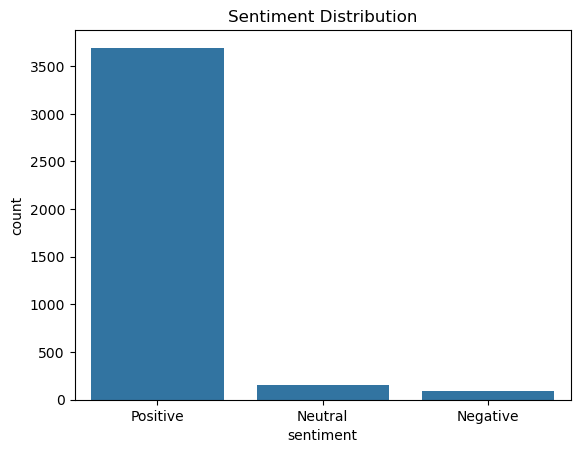

In [43]:
sns.countplot(x="sentiment",data=trainDf)
plt.title("Sentiment Distribution")
plt.show()
# Univariate analysis was performed on the sentiment variable
# The distribution shows class imbalance among sentiment categories

### length distribution

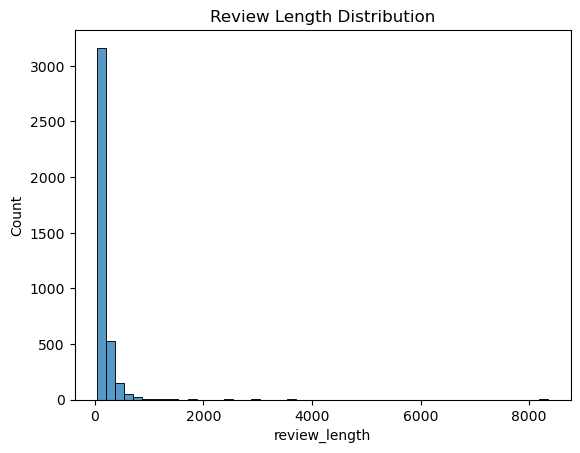

In [44]:
trainDf["review_length"]=trainDf["reviews.text"].apply(len)
sns.histplot(trainDf["review_length"],bins=50) # Divide the data into 50 intervals(bars)
plt.title("Review Length Distribution")
plt.show()
# Review length distribution was analyzed to understand variation in the size of textual data

### bivariate analysis

**sentiment vs review_length**

C:\Users\ajayk\AppData\Local\Temp\ipykernel_14236\1296188789.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sentiment",y="review_length",data=trainDf,palette="Set2")


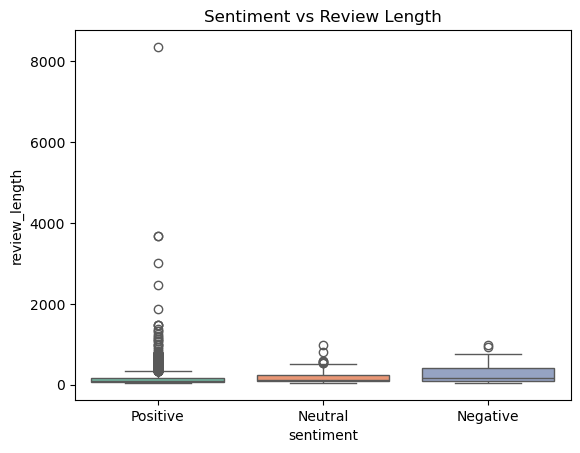

In [45]:
sns.boxplot(x="sentiment",y="review_length",data=trainDf,palette="Set2")
plt.title("Sentiment vs Review Length")
plt.show()
# Bivariate analysis between sentiment and review_length was performed to observe how text length varies across sentiment classes

### multivariate analysis

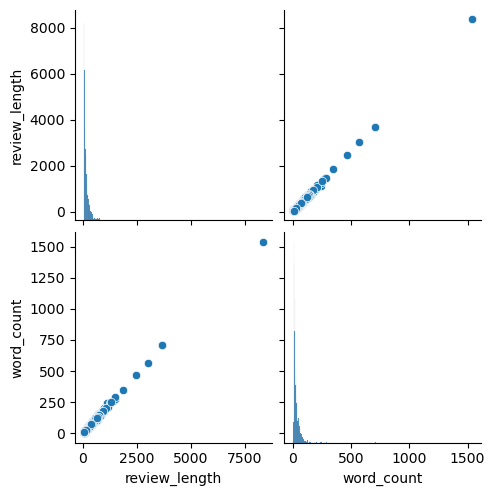

<Figure size 1000x1000 with 0 Axes>

In [46]:
# create a temporary numeric feature word_count → counts actual words
trainDf["word_count"]=trainDf["reviews.text"].apply(lambda x:len(str(x).split()))

# pairplot(multivariate visualization)
sns.pairplot(trainDf[["review_length","word_count"]])
plt.figure(figsize=(10,10))
plt.show()
# Multivariate analysis was conducted using review_length and word_count to explore relationships between multiple text-based features

### text analysis

In [47]:
from collections import Counter

Top 10 Common Words: [('the', 4455), ('to', 3902), ('and', 3859), ('I', 3398), ('for', 2787), ('a', 2622), ('it', 2371), ('is', 2354), ('my', 1848), ('this', 1446)]


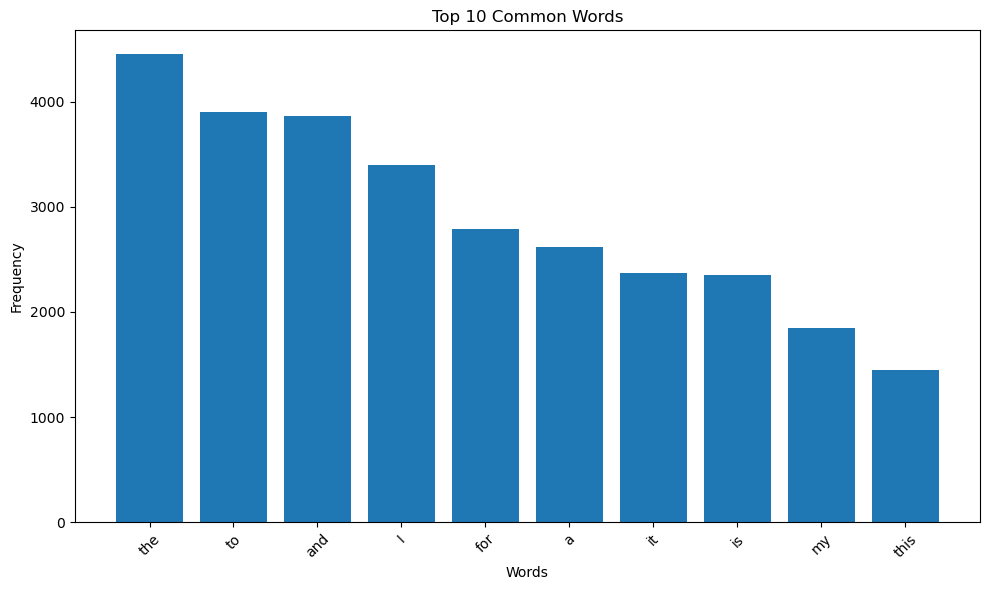

In [49]:
# most common words
all_words=" ".join(trainDf["reviews.text"]).split()
common_words=Counter(all_words).most_common(10) # Frequently occuring words were identified to gain insights into common terms used in customer reviews
print("Top 10 Common Words:",common_words)
# separate word and count
words=[word for word,count in common_words]
counts=[count for word,count in common_words]

# plot
plt.figure(figsize=(10,6))
plt.bar(words,counts)
plt.title("Top 10 Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/top_words.png",dpi=300,bbox_inches="tight")
plt.show()
# The bar chart displays the ten most frequently occurring words after text preprocessing
# These words represent the dominant vocabulary in customer reviews and provide insight into commonly discussed topics

### text preprocessing

In [50]:
import re # regular expression library
import nltk # natural language toolkit
from nltk.corpus import stopwords # corpus-collection of datasets,stopwords-list of common words

In [51]:
# downloading stopwords
nltk.download("stopwords")
stop_words=set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ajayk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [52]:
# function to clean text
def clean_text(text):
    text=str(text).lower() # convert into the lowercase
    text=re.sub("[^a-zA-Z]"," ",text) # remove special characters
    words=text.split()
    words=[w for w in words if w not in stop_words] # remove stopwords
    return" ".join(words)

In [53]:
# replace everything that is NOT a letter (a–z or A–Z) with a space
# re.sub-regualar expression substitution

In [54]:
# applying cleaning
trainDf["clean_review"]=trainDf["reviews.text"].apply(clean_text)
testDf["clean_review"]=trainDf["reviews.text"].apply(clean_text)
hiddenDf["clean_review"]=hiddenDf["reviews.text"].apply(clean_text)

In [55]:
# text preprocessing was performed by converting text to lowercase,removing special characters,
# and eliminating stopwords to improve data quality and model perfomance

### feature engineering(TF-IDF)

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [57]:
# TF-IDF
tfidf=TfidfVectorizer(max_features=5000)
# fit only on train data
X_train=tfidf.fit_transform(trainDf["clean_review"]).toarray()
# apply same vocabulary to other datasets
X_test=tfidf.transform(testDf["clean_review"]).toarray() # To ensure the same feature space is used across all datasets and avoid mismatch in feature dimensions
X_hidden=tfidf.transform(hiddenDf["clean_review"]).toarray()
# target
y_train=trainDf["sentiment"]

from sklearn.model_selection import train_test_split
X=X_train
y=y_train

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2410)
# TF-IDF(Term Frequency-Inverse Document Frequency) was used to convert the textual data into numerical features suitable for machine learning models

### handle class imbalance

In [58]:
from imblearn.over_sampling import RandomOverSampler # imblearn-imbalanced learn library

In [59]:
X_train,y_train=RandomOverSampler().fit_resample(X_train,y_train)
# fit()-Understand class distribution
# resample()-Balance the dataset
# Class imbalance in the dataset was addressed using oversampling to ensure balanced representation of all sentiment classes

### naive bayes model

In [60]:
from sklearn.naive_bayes import MultinomialNB

In [61]:
nb=MultinomialNB().fit(X_train,y_train)

### prediction

In [62]:
y_pred_nb=nb.predict(X_test)

### evaluation metrics

In [64]:
from sklearn.metrics import confusion_matrix,classification_report

In [65]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

    Negative       0.22      0.57      0.31        14
     Neutral       0.18      0.41      0.25        29
    Positive       0.97      0.89      0.93       746

    accuracy                           0.87       789
   macro avg       0.46      0.63      0.50       789
weighted avg       0.93      0.87      0.90       789



In [66]:
# Naive bayes classifier was implemented as a baseline model due to its efficiency in handling text classification tasks

### confusion matrix

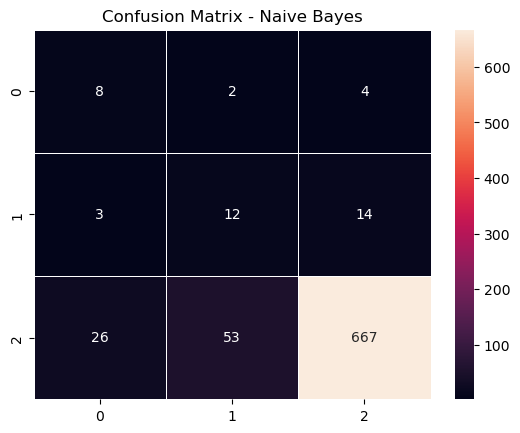

In [67]:
sns.heatmap(confusion_matrix(y_test,y_pred_nb),annot=True,fmt="d",linewidths=0.5) # 'd'-integer format(decimal)/Display numbers as whole numbers(integers)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()
# Confusion matrix was used to visualize model performance by comparing actual and predicted values

### svm model

In [68]:
from sklearn.svm import LinearSVC # Very fast and recommended for NLP(Natural Language Processing)

In [69]:
svm=LinearSVC().fit(X_train,y_train)

### prediction

In [70]:
y_pred_svm=svm.predict(X_test)

### evaluation metrics

In [71]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

    Negative       0.43      0.21      0.29        14
     Neutral       0.38      0.21      0.27        29
    Positive       0.96      0.98      0.97       746

    accuracy                           0.94       789
   macro avg       0.59      0.47      0.51       789
weighted avg       0.93      0.94      0.93       789



In [72]:
# Support vector machine(SVM) was used as an advanced model to improve classification performance by finding optimal decision boundaries

### confusion matrix(linear SVM)

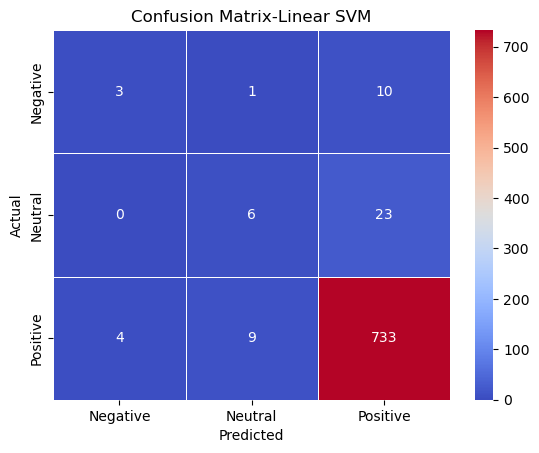

In [76]:
sns.heatmap(confusion_matrix(y_test,y_pred_svm),annot=True,fmt="d",cmap="coolwarm",linewidths=0.5,xticklabels=svm.classes_,yticklabels=svm.classes_)
plt.title("Confusion Matrix-Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/confusion_matrix_svm.png",dpi=300,bbox_inches="tight")
plt.show()
# The confusion matrix shows that the Linear SVM correctly classified most customer reviews with only a few misclassifications,indicating strong classification performance

### LSTM model

In [78]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.3/351.2 MB 10.1 MB/s eta 0:00:35
   ---------------------------------------- 3.7/351.2 MB 11.3 MB/s eta 0:00:31
    --------------------------------------- 5.5/351.2 MB 10.1 MB/s eta 0:00:35
    --------------------------------------- 6.3/351.2 MB 8.6 MB/s eta 0:00:40
    --------------------------------------- 7.1/351.2 MB 7.3 MB/s eta 0:00:47
    --------------------------------------- 7.6/351.2 MB 6.6 MB/s eta 0:00:53
    --------------------------------------- 8.1/351.2 MB 6.2 MB/s eta 0:00:56
   - -------------------------------------- 8.9/351.2 MB 5.6 MB/s eta 0:01:02
   - -------------------------------------- 9.4/351.2 MB 5.3 MB/s eta 0:01:05
   - -------------------------------------- 10.2/351.2 MB 5.0 MB/s eta 0:01:08
   - -------------------------------------- 10.7/351.2 MB 4.9 MB/s eta 0:01:10
   - -------------------------------------- 11.5/351.2 MB 4.7 MB/s

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.0 which is incompatible.


In [77]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import LSTM,Dense,Embedding,Dropout
from tensorflow.keras.utils import to_categorical

In [78]:
tokenizer=Tokenizer(num_words=5000,oov_token="<OOV>") # "<OOV>"-Out Of Vocabulary(Handles unknown words)
tokenizer.fit_on_texts(trainDf["clean_review"])

X_train_seq=tokenizer.texts_to_sequences(trainDf["clean_review"])
X_test_seq=tokenizer.texts_to_sequences(testDf["clean_review"])
X_hidden_seq=tokenizer.texts_to_sequences(hiddenDf["clean_review"])

max_len=100
X_train_seq=pad_sequences(X_train_seq,maxlen=max_len)
X_test_seq=pad_sequences(X_test_seq,maxlen=max_len)
X_hidden_seq=pad_sequences(X_hidden_seq,maxlen=max_len)

le=LabelEncoder()
y_train_lstm=to_categorical(le.fit_transform(trainDf["sentiment"]))
X_train_seq,X_test_seq,y_train_lstm,y_test_lstm=train_test_split(X_train_seq,y_train_lstm,test_size=0.2,random_state=2410)

lstm_model=Sequential()
# 5000- vocabulary size
# 128- vector size (embedding dimension)
# max_len- length of each sequence
lstm_model.add(Embedding(5000,128,input_length=max_len)) # lstm_model.add(Embedding(5000,128,input_length=max_len))-Converts word indices -> dense vectors
lstm_model.add(LSTM(64)) # LSTM(64)-number of memory units(neurons)-How much the model can learn patterns from text
lstm_model.add(Dropout(0.5)) # Dropout(0.5)-prevent overfitting(drop 50% neurons during training)
lstm_model.add(Dense(3,activation="softmax")) # Dense(3,activation="softmax")- 3=number of classes(Positive,Negative,Neutral),softmax -> gives probability output
lstm_model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=["accuracy"])
# Loss("categorical_crossentropy")-Used for multi-class classification
# optimizer='adam'-Adjusts weights efficiently
# metrics=['accuracy']-Measures performance
history=lstm_model.fit(X_train_seq,y_train_lstm,epochs=5,batch_size=64,validation_data=(X_test_seq,y_test_lstm)) 
# epochs=5- Number of times model sees entire data(5 epochs = model learns 5 times)
# batch_size=64- Number of samples processed at once(Model trains in chunks of 64 rows and Not whole dataset at once)
loss,acc=lstm_model.evaluate(X_test_seq,y_test_lstm)
print("LSTM Accuracy:",acc)

C:\Users\ajayk\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 207ms/step - accuracy: 0.9226 - loss: 0.4215 - val_accuracy: 0.9455 - val_loss: 0.2370
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 0.9359 - loss: 0.2750 - val_accuracy: 0.9455 - val_loss: 0.2287
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - accuracy: 0.9423 - loss: 0.2382 - val_accuracy: 0.9468 - val_loss: 0.2196
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.9524 - loss: 0.1659 - val_accuracy: 0.9442 - val_loss: 0.2128
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.9680 - loss: 0.1006 - val_accuracy: 0.9442 - val_loss: 0.2330
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9442 - loss: 0.2330 
LSTM Accuracy: 0.9442331790924072


In [76]:
# LSTM(Long Short-Term Memory) model was implemented to capture sequential patterns in text data and improve prediction accuracy

### LSTM accuracy graph

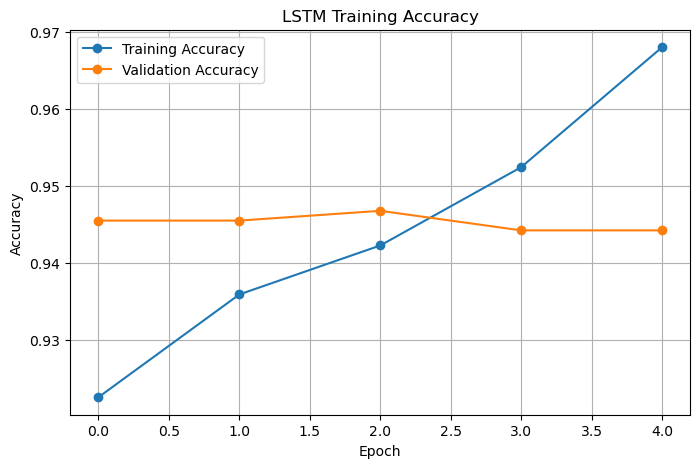

In [80]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],marker="o",label="Training Accuracy")
plt.plot(history.history["val_accuracy"],marker="o",label="Validation Accuracy")
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("images/lstm_accuracy.png",dpi=300,bbox_inches="tight")
plt.show()
# The training and validation accuracy graph illustrates how the model's performance improved over each training epoch
# Both curves show an increasing trend, indicating that the model successfully learned meaningful patterns from customer reviews
# The close alignment of the two curves suggests good generalization without significant overfitting

### LSTM loss graph

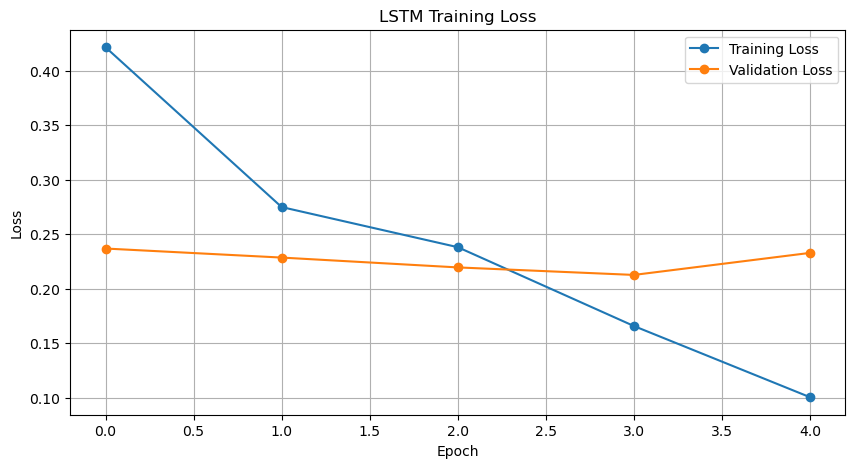

In [81]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"],marker="o",label="Training Loss")
plt.plot(history.history["val_loss"],marker="o",label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("images/lstm_loss.png",dpi=300,bbox_inches="tight")
plt.show()
# The training and validation loss graph demonstrates that the loss decreased steadily over successive epochs
# This indicates that the model minimized prediction errors during training and converged effectively
# The similar trend of both curves suggests stable learning and good model performance

### final prediction

In [82]:
hidden_pred=nb.predict(X_hidden)
hiddenDf["predicted_sentiment"]=hidden_pred
hiddenDf.to_csv("final_predictions.csv",index=False)
# The trained model was applied to hidden/unseen data to generate final predictions,which were saved for evaluation